In [11]:
# imports
import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from retinaface import RetinaFace

from insightface.app import FaceAnalysis

In [12]:
TINYFACE_CSV = "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/celebrity_dataset.csv"

In [13]:
# loading the model
class MLPExperiment(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )

    def forward(self, x):

        return self.network(x)

In [14]:
model = MLPExperiment()

model.load_state_dict(
    torch.load("/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/saved_models/A2_similarity_margin_model.pth", map_location=torch.device("cpu"))
)

model.eval()

print("MLP Loaded")

MLP Loaded


In [15]:
# loading the scaler
scaler = joblib.load("/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/saved_scalers/A2_similarity_margin_scaler.pkl")

print("Scaler Loaded")

Scaler Loaded


In [16]:
# evaluation function
def evaluate_dataset(csv_file):

    df = pd.read_csv(csv_file)

    X = df[["best_similarity", "margin"]]

    y_true = df["label"]

    X_scaled = scaler.transform(X)

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():

        outputs = model(X_tensor)
        probs=torch.softmax(outputs, dim=1)
        print(probs[:20])
        y_pred=torch.argmax(outputs, dim=1).numpy()

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)

    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [17]:
# threshold evaluation
def evaluate_threshold(csv_file):

    df = pd.read_csv(csv_file)

    y_true = df["label"]

    threshold_pred = (df["best_similarity"] >= 0.6).astype(int)

    accuracy = accuracy_score(y_true, threshold_pred)

    precision = precision_score(y_true, threshold_pred, zero_division=0)

    recall = recall_score(y_true, threshold_pred, zero_division=0)

    f1 = f1_score(y_true, threshold_pred, zero_division=0)

    cm = confusion_matrix(y_true, threshold_pred)

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        TAR = TP / (TP + FN) if (TP + FN) > 0 else np.nan

        FRR = FN / (TP + FN) if (TP + FN) > 0 else np.nan

        TRR = TN / (TN + FP) if (TN + FP) > 0 else np.nan

        FAR = FP / (TN + FP) if (TN + FP) > 0 else np.nan

    else:

        TAR = np.nan
        FRR = np.nan
        TRR = np.nan
        FAR = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TAR": TAR,
        "FRR": FRR,
        "TRR": TRR,
        "FAR": FAR,
        "y_true": y_true,
        "y_pred": threshold_pred,
    }

In [18]:
# running our multi layer MLP
mlp_result = evaluate_dataset(TINYFACE_CSV)

print("\nA2: Similarity and Margin")
print("===================")

for k, v in mlp_result.items():

    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v:.4f}")

tensor([[3.6021e-02, 9.6398e-01],
        [5.5907e-01, 4.4093e-01],
        [5.2567e-01, 4.7433e-01],
        [5.6429e-01, 4.3571e-01],
        [6.7925e-04, 9.9932e-01],
        [5.3837e-01, 4.6163e-01],
        [1.1317e-01, 8.8683e-01],
        [5.8091e-01, 4.1909e-01],
        [4.9056e-01, 5.0944e-01],
        [5.1840e-01, 4.8160e-01],
        [3.8085e-02, 9.6191e-01],
        [5.6196e-01, 4.3804e-01],
        [3.0906e-01, 6.9094e-01],
        [5.3526e-01, 4.6474e-01],
        [5.7170e-01, 4.2830e-01],
        [5.6551e-01, 4.3449e-01],
        [5.8116e-01, 4.1884e-01],
        [5.8116e-01, 4.1884e-01],
        [1.7782e-01, 8.2218e-01],
        [5.8079e-01, 4.1921e-01]])

A2: Similarity and Margin
Accuracy: 0.7950
Precision: 1.0000
Recall: 0.5900
F1: 0.7421
TAR: 0.5900
FRR: 0.4100
TRR: 1.0000
FAR: 0.0000


In [19]:
# running fixed threshold method
threshold_result = evaluate_threshold(TINYFACE_CSV)

print("\nTHRESHOLD RESULTS")
print("===================")

for k, v in threshold_result.items():

    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v:.4f}")


THRESHOLD RESULTS
Accuracy: 0.5200
Precision: 1.0000
Recall: 0.0400
F1: 0.0769
TAR: 0.0400
FRR: 0.9600
TRR: 1.0000
FAR: 0.0000


In [20]:
# final comparison
comparison = pd.DataFrame(
    [
        {
            "Method": "Threshold",
            "Accuracy": threshold_result["Accuracy"],
            "Precision": threshold_result["Precision"],
            "Recall": threshold_result["Recall"],
            "F1": threshold_result["F1"],
            "TAR": threshold_result["TAR"],
            "FRR": threshold_result["FRR"],
            "TRR": threshold_result["TRR"],
            "FAR": threshold_result["FAR"],
        },
        {
            "Method": "A2: Similarity and Margin",
            "Accuracy": mlp_result["Accuracy"],
            "Precision": mlp_result["Precision"],
            "Recall": mlp_result["Recall"],
            "F1": mlp_result["F1"],
            "TAR": mlp_result["TAR"],
            "FRR": mlp_result["FRR"],
            "TRR": mlp_result["TRR"],
            "FAR": mlp_result["FAR"],
        },
    ]
)

display(comparison.round(4))

,Method,Accuracy,Precision,Recall,F1,TAR,FRR,TRR,FAR
0,Threshold,0.520,1.0,0.04,0.0769,0.04,0.96,1.0,0.0
1,A2: Similarity and Margin,0.795,1.0,0.59,0.7421,0.59,0.41,1.0,0.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix

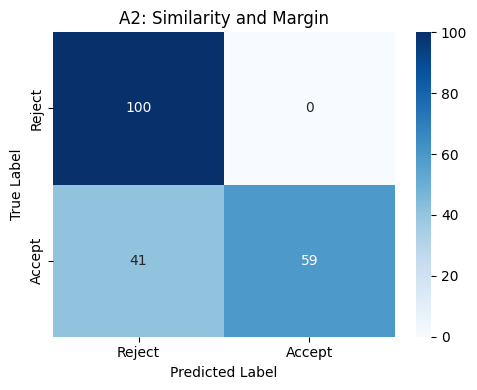

In [22]:
# -------------------------
# MLP Confusion Matrix
# -------------------------

cm = confusion_matrix(
    mlp_result["y_true"],
    mlp_result["y_pred"],
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"],
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("A2: Similarity and Margin")

plt.tight_layout()

plt.savefig(
    "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/ablation_study_figures/A2_SimMarg/mlp_A2_tinyface_cm.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

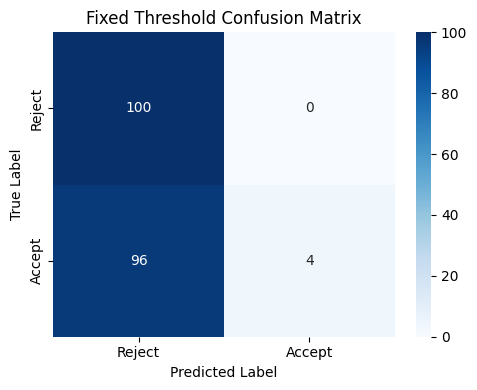

In [23]:
# -------------------------
# Threshold Confusion Matrix
# -------------------------

cm = confusion_matrix(
    threshold_result["y_true"],
    threshold_result["y_pred"],
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"],
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fixed Threshold Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/Users/admin/Desktop/reliable_rejection_under_degradation/ablation_study/ablation_study_figures/A2_SimMarg/threshold_tinyface_cm.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [24]:
df = pd.read_csv(TINYFACE_CSV)

print("\nLabel Counts")
print(df["label"].value_counts())

print("\nOverall Similarity")
print(df["best_similarity"].describe())

print("\nOverall Margin")
print(df["margin"].describe())

print("\nPositive Similarities")
print(df[df["label"] == 1]["best_similarity"].describe())

print("\nNegative Similarities")
print(df[df["label"] == 0]["best_similarity"].describe())

print("\nPositive Margins")
print(df[df["label"] == 1]["margin"].describe())

print("\nNegative Margins")
print(df[df["label"] == 0]["margin"].describe())

print("\nPredicted Accepts (MLP)")
print(mlp_result["y_pred"].sum())


Label Counts
label
1    100
0    100
Name: count, dtype: int64

Overall Similarity
count    200.000000
mean       0.279617
std        0.144405
min       -0.027753
25%        0.165137
50%        0.215180
75%        0.383425
max        0.751467
Name: best_similarity, dtype: float64

Overall Margin
count    200.000000
mean       0.121734
std        0.134604
min       -0.166733
25%        0.013649
50%        0.058100
75%        0.224874
max        0.618040
Name: margin, dtype: float64

Positive Similarities
count    100.000000
mean       0.389100
std        0.128716
min       -0.027753
25%        0.299714
50%        0.383637
75%        0.471106
max        0.751467
Name: best_similarity, dtype: float64

Negative Similarities
count    100.000000
mean       0.170133
std        0.033658
min        0.102145
25%        0.145794
50%        0.165930
75%        0.189589
max        0.286501
Name: best_similarity, dtype: float64

Positive Margins
count    100.000000
mean       0.218967
std        0.

In [25]:
print("\nActual Accepts")
print(df["label"].sum())


Actual Accepts
100


In [26]:
print(df[["quality_score", "best_similarity", "margin"]].describe())

       quality_score  best_similarity      margin
count     200.000000       200.000000  200.000000
mean       20.962221         0.279617    0.121734
std         2.457069         0.144405    0.134604
min        15.659685        -0.027753   -0.166733
25%        19.367360         0.165137    0.013649
50%        20.499352         0.215180    0.058100
75%        22.719759         0.383425    0.224874
max        26.945877         0.751467    0.618040
